In [1]:
from helperfunctions import helper as hfn
from helperfunctions import training_lib as tl
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from helperfunctions import controlled_env as ce
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter, MaxNLocator, AutoMinorLocator
from typing import Dict,Optional
import pandas as pd
import numpy as np
import torch.nn as nn
from glob import glob
import os
from pathlib import Path
import pandas as pd
#%matplotlib widget


In [2]:
fn_train = "train_eval_df.csv"
fn_val1 = "val1_eval_df.csv"
fn_val2  = "val2_eval_df.csv"

In [3]:
path  = ic.PATH_PART2_EVAL
os.makedirs(path, exist_ok=True)
if not Path(path /"train_eval_df.csv").exists():
    cfg1 = hfn.TrainConfig(config_name="kde", choose_val_set=1)
    cfg2 = hfn.TrainConfig(config_name="kde", choose_val_set=2)
    print(f"val1 start: {cfg1.val_start_time}, end:{cfg1.val_end_time}")
    print(f"val2 start: {cfg2.val_start_time}, end:{cfg2.val_end_time}")
    ae_best = tl.get_model_results(ic.PATH_TO_BEST_MODEL_DIR, best_n=1)
    ae, _,_,_,_ = ae_best[0]
    ae = ae.to(cfg1.device).eval()
    print(ae)
    
    train_loader, val1_loader, _ = hfn.build_dataloaders(
    train_csv_dir=ic.PATH_PC_FILTERING,
    val_csv_dir=ic.PATH_IMPUTED,
    test_csv_dir=ic.PATH_IMPUTED,
    cfg=cfg1
    )
    train_eval_df = tl.eval_model(
    model=ae,
    data_loader=train_loader,
    device=cfg1,
    loss_fn = nn.MSELoss(reduction="none")
    )
    train_loader = None
    train_eval_df.to_csv(path /fn_train, index=False)
    
    val1_eval_df = tl.eval_model(
    model=ae,
    data_loader=val1_loader,
    device=cfg1,
    loss_fn = nn.MSELoss(reduction="none"),
    )
    val1_loader = None
    val1_eval_df.to_csv(path/fn_val1, index=False)
    
    _, val2_loader, _ = hfn.build_dataloaders(
    train_csv_dir=ic.PATH_PC_FILTERING,
    val_csv_dir=ic.PATH_IMPUTED,
    test_csv_dir=ic.PATH_IMPUTED,
    cfg=cfg2)
    
    val2_eval_df = tl.eval_model(
    model=ae,
    data_loader=val2_loader,
    device=cfg2,
    loss_fn = nn.MSELoss(reduction="none"),
    )
    val2_loader = None
    val2_eval_df.to_csv(path/fn_val2, index=False)

else:
    train_eval_df = pd.read_csv(path/fn_train)
    val1_eval_df = pd.read_csv(path/fn_val1)
    val2_eval_df = pd.read_csv(path/fn_val2)



In [4]:
fs = glob(os.path.join(ic.PATH_PART2_EVAL_TEST, "*.csv"))
print(fs)
test_eval_df = pd.read_csv(fs[0])

['C:\\Users\\admin\\Uni\\Abschlussarbeit\\github\\BSc-Thesis-Multi-Wind-Turbine-AD\\src\\Penmanshiel\\processed_data\\signal_imputation\\part2\\eval_test_set\\eval_test_set.csv']


### KDE Plot per Turbine
Model output RE (MSE)<br>
Used Kernel: Gaussian<br>
bandwith-factor for 1d: variance of the kernel covariance<br>

In [5]:
display(train_eval_df.head())

,uid,Date and time,WT_ID,Mean Loss per Sample,RE_Ambient temperature (converter) (°C),RE_Drive train acceleration (mm/ss),RE_Gear oil inlet pressure (bar),RE_Gear oil pump pressure (bar),RE_Gearbox speed (RPM),RE_Generator bearing front temperature (°C),...,RE_Blade angle (pitch position) C (°),RE_Front bearing temperature (°C),RE_Gear oil inlet temperature (°C),RE_Gear oil temperature (°C),RE_Rear bearing temperature (°C),RE_Tower Acceleration X (mm/ss),RE_Tower Acceleration Y (mm/ss),RE_Transformer cell temperature (°C),RE_Transformer temperature (°C),RE_Yaw bearing angle (°)
0,1522969800000000001,2018-04-05 23:10:00,1,0.008333,0.000019,0.081245,0.031271,0.023004,0.000703,0.001590,...,0.002786,0.000172,0.000547,0.006259,0.000947,5.017730e-04,0.016234,1.448158e-03,6.131495e-04,4.185428e-05
1,1522969800000000002,2018-04-05 23:10:00,2,0.008966,0.001109,0.152468,0.003168,0.013334,0.000337,0.008372,...,0.001094,0.000740,0.000664,0.013578,0.008250,8.228723e-07,0.015145,1.606885e-03,1.494202e-02,9.354847e-07
2,1522969800000000004,2018-04-05 23:10:00,4,0.002122,0.004425,0.000379,0.002071,0.006877,0.003332,0.000008,...,0.000315,0.000399,0.001237,0.002412,0.000253,3.728784e-03,0.003940,6.180873e-07,5.960750e-07,1.008522e-04
3,1522969800000000005,2018-04-05 23:10:00,5,0.005604,0.000158,0.043029,0.008393,0.022307,0.000010,0.018557,...,0.000165,0.000266,0.001962,0.016440,0.004577,7.720152e-03,0.004935,1.586779e-02,5.458017e-04,9.014069e-05
4,1522969800000000006,2018-04-05 23:10:00,6,0.006717,0.010819,0.056578,0.000020,0.002590,0.000367,0.001217,...,0.000459,0.001104,0.001774,0.001739,0.000338,4.525194e-03,0.001746,8.254393e-03,8.811328e-03,1.674965e-05


In [6]:
wts = [1,2,4,5,6,7,8,9,10,11,12,13,14,15]
cmap = plt.get_cmap("tab20", len(wts))
color_map = {wt: cmap(i) for i, wt in enumerate(wts)}

In [7]:

def print_kdes(df:pd.DataFrame,
               wts: list[int] = [1,2,4,5,6,7,8,9,10,11,12,13,14,15],
               ncols: int = 1,
               title: str = "",
               dpi:int=300,
               filename:Optional[str] = None,
               xlim: Optional[float] = None,
               show_global_max = False,
               all_in_one = False,
               ):
    cmap = plt.get_cmap("tab20", len(wts))
    color_map = {wt: cmap(i) for i, wt in enumerate(wts)}
    
    if not all_in_one:
        n = len(wts)
        nrows = (n + ncols - 1) // ncols
        
        fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.5*nrows), sharex=False, sharey=False)
        axes = np.array(axes).ravel()
        global_max = pd.to_numeric(df[ic.MEAN_LOSS_PER_SAMPLE]).max()
        for i, wt in enumerate(wts):
            ax = axes[i]
            wt_df = df[df[ic.WT_ID] == wt]
            re = pd.to_numeric(wt_df[ic.MEAN_LOSS_PER_SAMPLE])
            
            x_max = re.max() if xlim is None else xlim
            
            re.plot.kde(ax=ax, label=f"WT {wt}", color=color_map[wt]) #bandwith method "scott"
            ax.set_xlim(0.0, global_max if show_global_max else x_max)
            ax.set_xlabel("Reconstruction Error")
            ax.set_ylabel("Density")
            ax.set_title(f"KDE WT:{wt}")
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)

        for j in range(i+1, len(axes)):
            axes[j].axis("off")
        
        major = 10
        minor = 5
        
        for ax in axes:
            if ax.axison:
                ax.xaxis.set_major_locator(MaxNLocator(nbins=major, prune=None))
                ax.xaxis.set_minor_locator(AutoMinorLocator(minor))
                ax.xaxis.set_minor_formatter(FormatStrFormatter("%.2f"))
                ax.tick_params(axis="x", which="minor", labelsize=7, pad=2)
                ax.tick_params(axis="x", which="major", labelsize=7)
                
                #ax.tick_params(axis="x", which="minor", labelbottom=False)
                #ax.set_xlabel("Reconstruction Error")
        fig.suptitle(f"{title}", y=1.02)
        
    else:
        fig,ax = plt.subplots(figsize=(8,4))
        global_max= 0.0
        for wt in wts:
            wt_df = train_eval_df[train_eval_df[ic.WT_ID] == wt]
            re = pd.to_numeric(wt_df[ic.MEAN_LOSS_PER_SAMPLE])
            global_max = max(global_max, re.max())    
            re.plot.kde(ax=ax, label=f"WT {wt}", color=color_map[wt]) #bandwith method "scott"

        ax.set_xlim(0.0, global_max if show_global_max else xlim if xlim is not None else 0.04)
        ax.set_xlabel("Reconstruction Error")
        ax.set_ylabel("Density")
        ax.set_title(f"KDE All WTs - {title}")
        ax.grid(True, alpha=0.3)
        ax.legend(ncol=2, fontsize=9)
        plt.tight_layout()
        plt.show()
    plt.tight_layout()
    if (filename is not None):
            fig.savefig(ic.PATH_PRINTS / filename, 
                        dpi = dpi, 
                        bbox_inches="tight"
                        )
    plt.show()

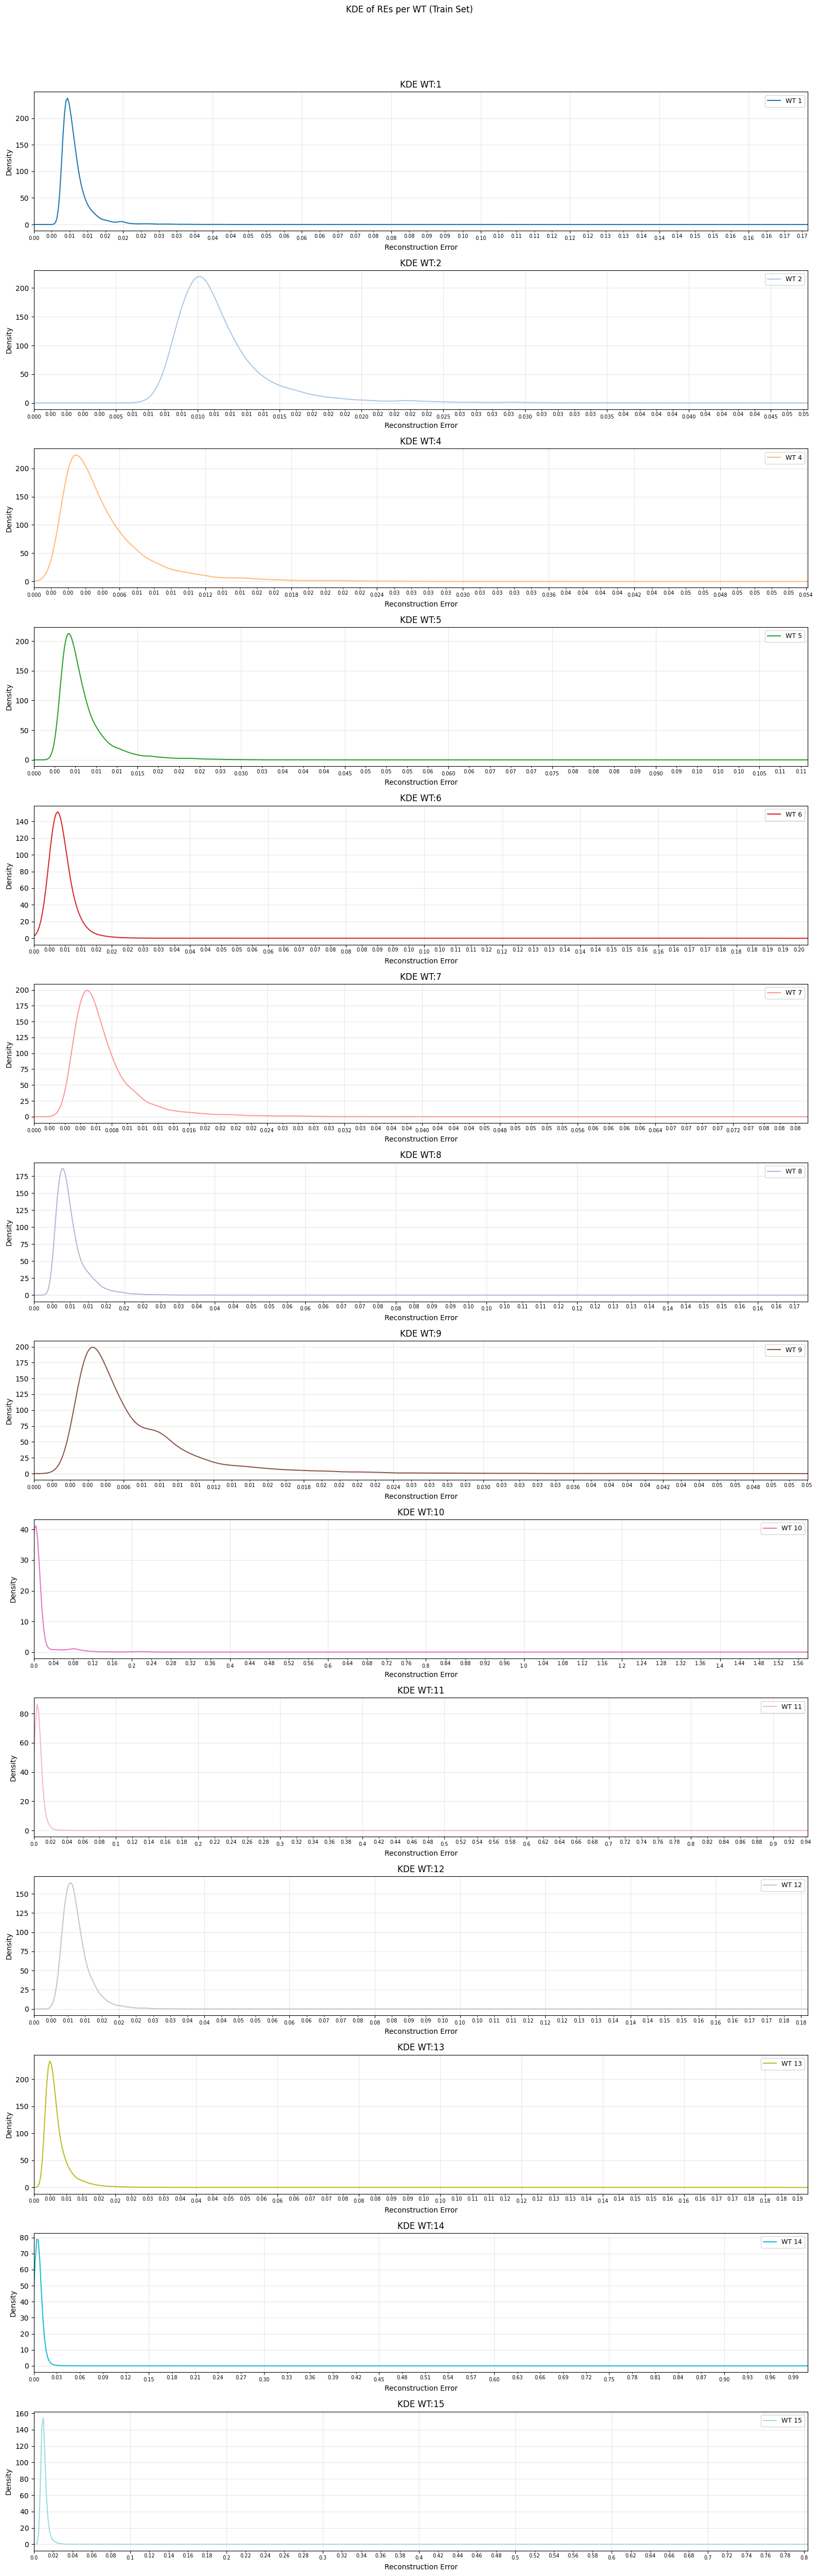

In [8]:
print_kdes(train_eval_df, title="KDE of REs per WT (Train Set)")

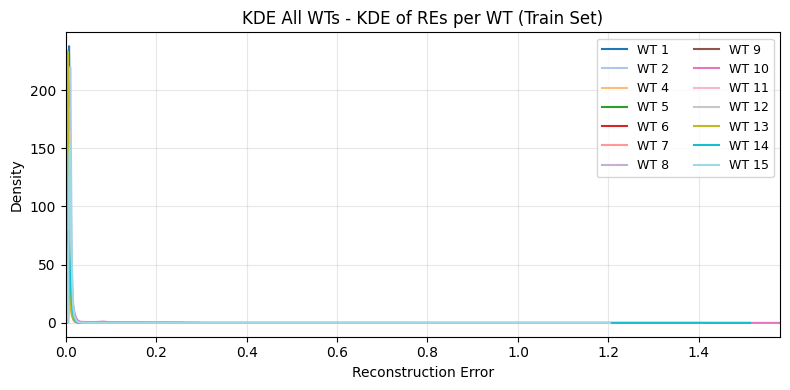

<Figure size 640x480 with 0 Axes>

In [9]:
print_kdes(train_eval_df, title="KDE of REs per WT (Train Set)", all_in_one=True, show_global_max=True)

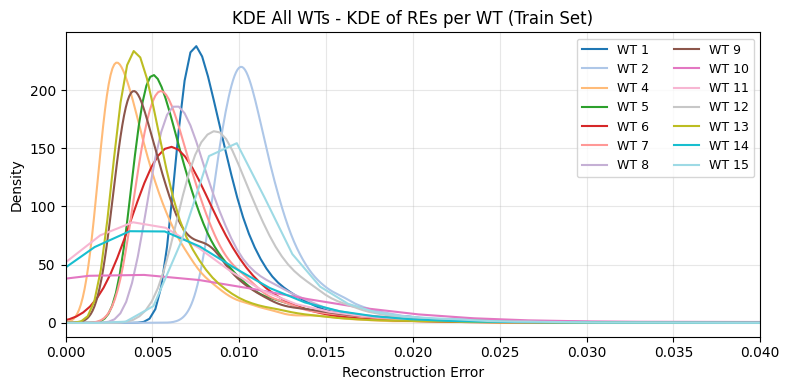

<Figure size 640x480 with 0 Axes>

In [10]:
print_kdes(train_eval_df, title="KDE of REs per WT (Train Set)", all_in_one=True, show_global_max=False, xlim=0.04)

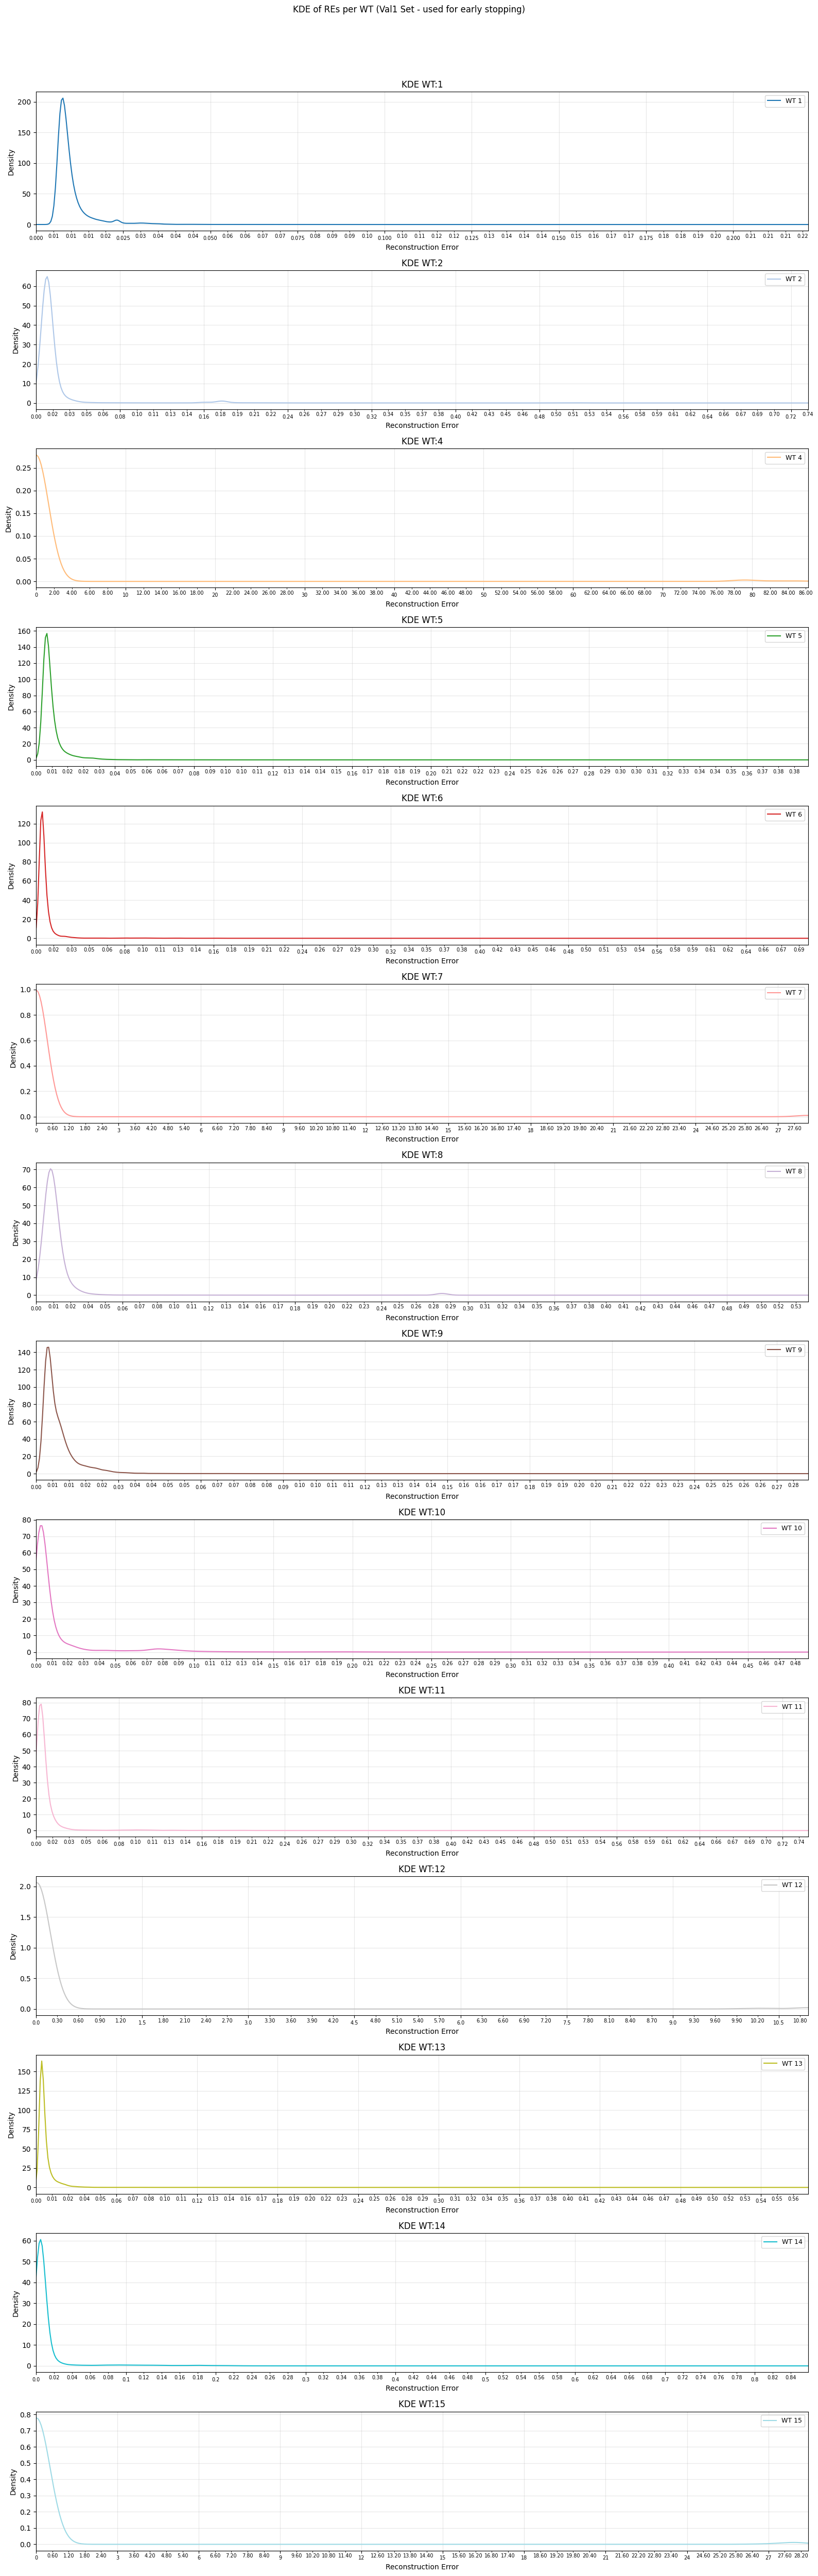

In [11]:
print_kdes(val1_eval_df, title="KDE of REs per WT (Val1 Set - used for early stopping)")

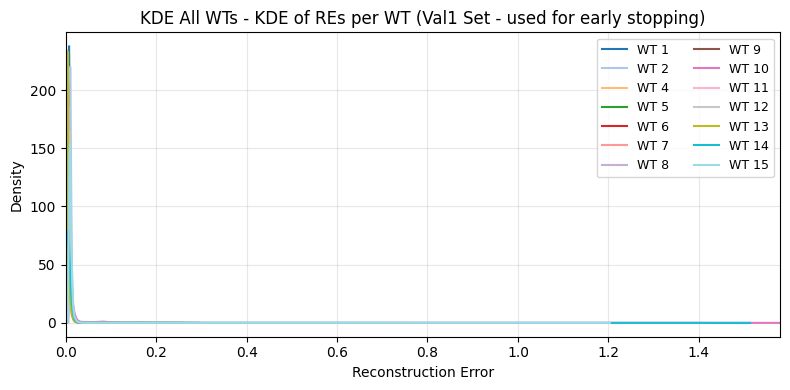

<Figure size 640x480 with 0 Axes>

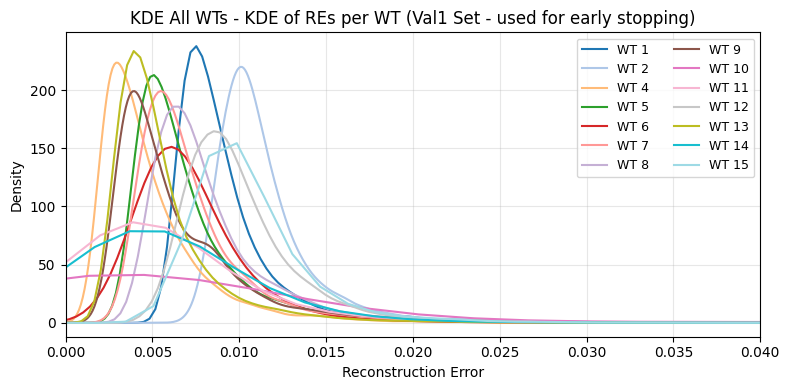

<Figure size 640x480 with 0 Axes>

In [12]:
print_kdes(val1_eval_df, title="KDE of REs per WT (Val1 Set - used for early stopping)", all_in_one=True, show_global_max=True)
print_kdes(val1_eval_df, title="KDE of REs per WT (Val1 Set - used for early stopping)", all_in_one=True, show_global_max=False, xlim=0.04)

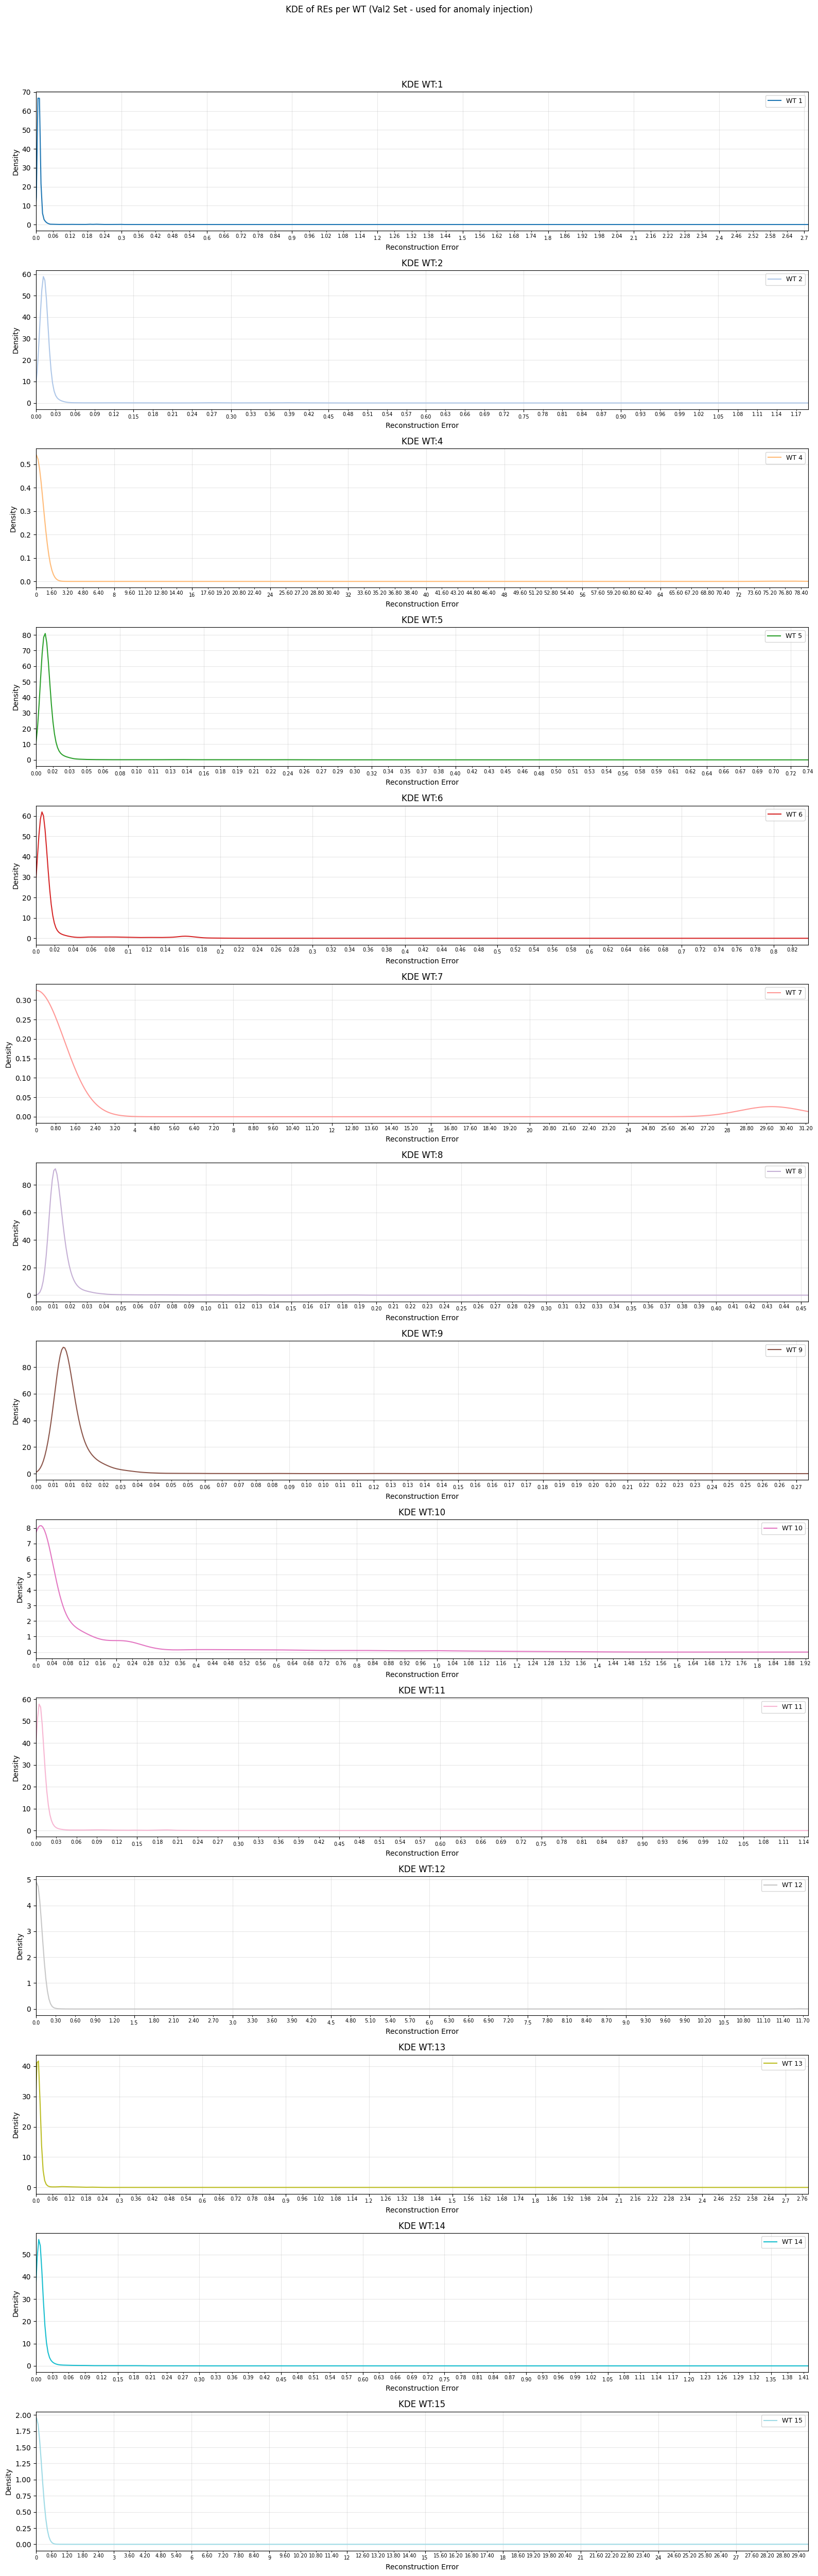

In [13]:
print_kdes(val2_eval_df, title="KDE of REs per WT (Val2 Set - used for anomaly injection)")

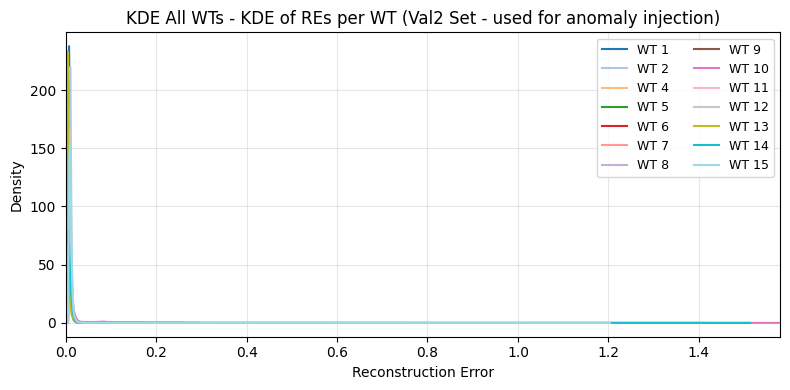

<Figure size 640x480 with 0 Axes>

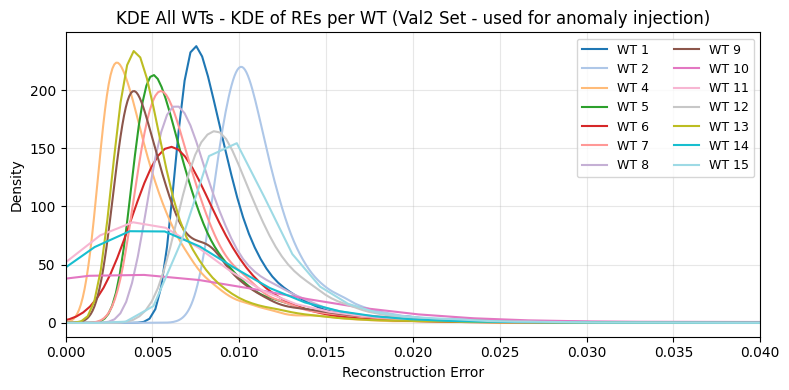

<Figure size 640x480 with 0 Axes>

In [14]:
print_kdes(val2_eval_df, title="KDE of REs per WT (Val2 Set - used for anomaly injection)", all_in_one=True, show_global_max=True)
print_kdes(val2_eval_df, title="KDE of REs per WT (Val2 Set - used for anomaly injection)", all_in_one=True, show_global_max=False, xlim=0.04)

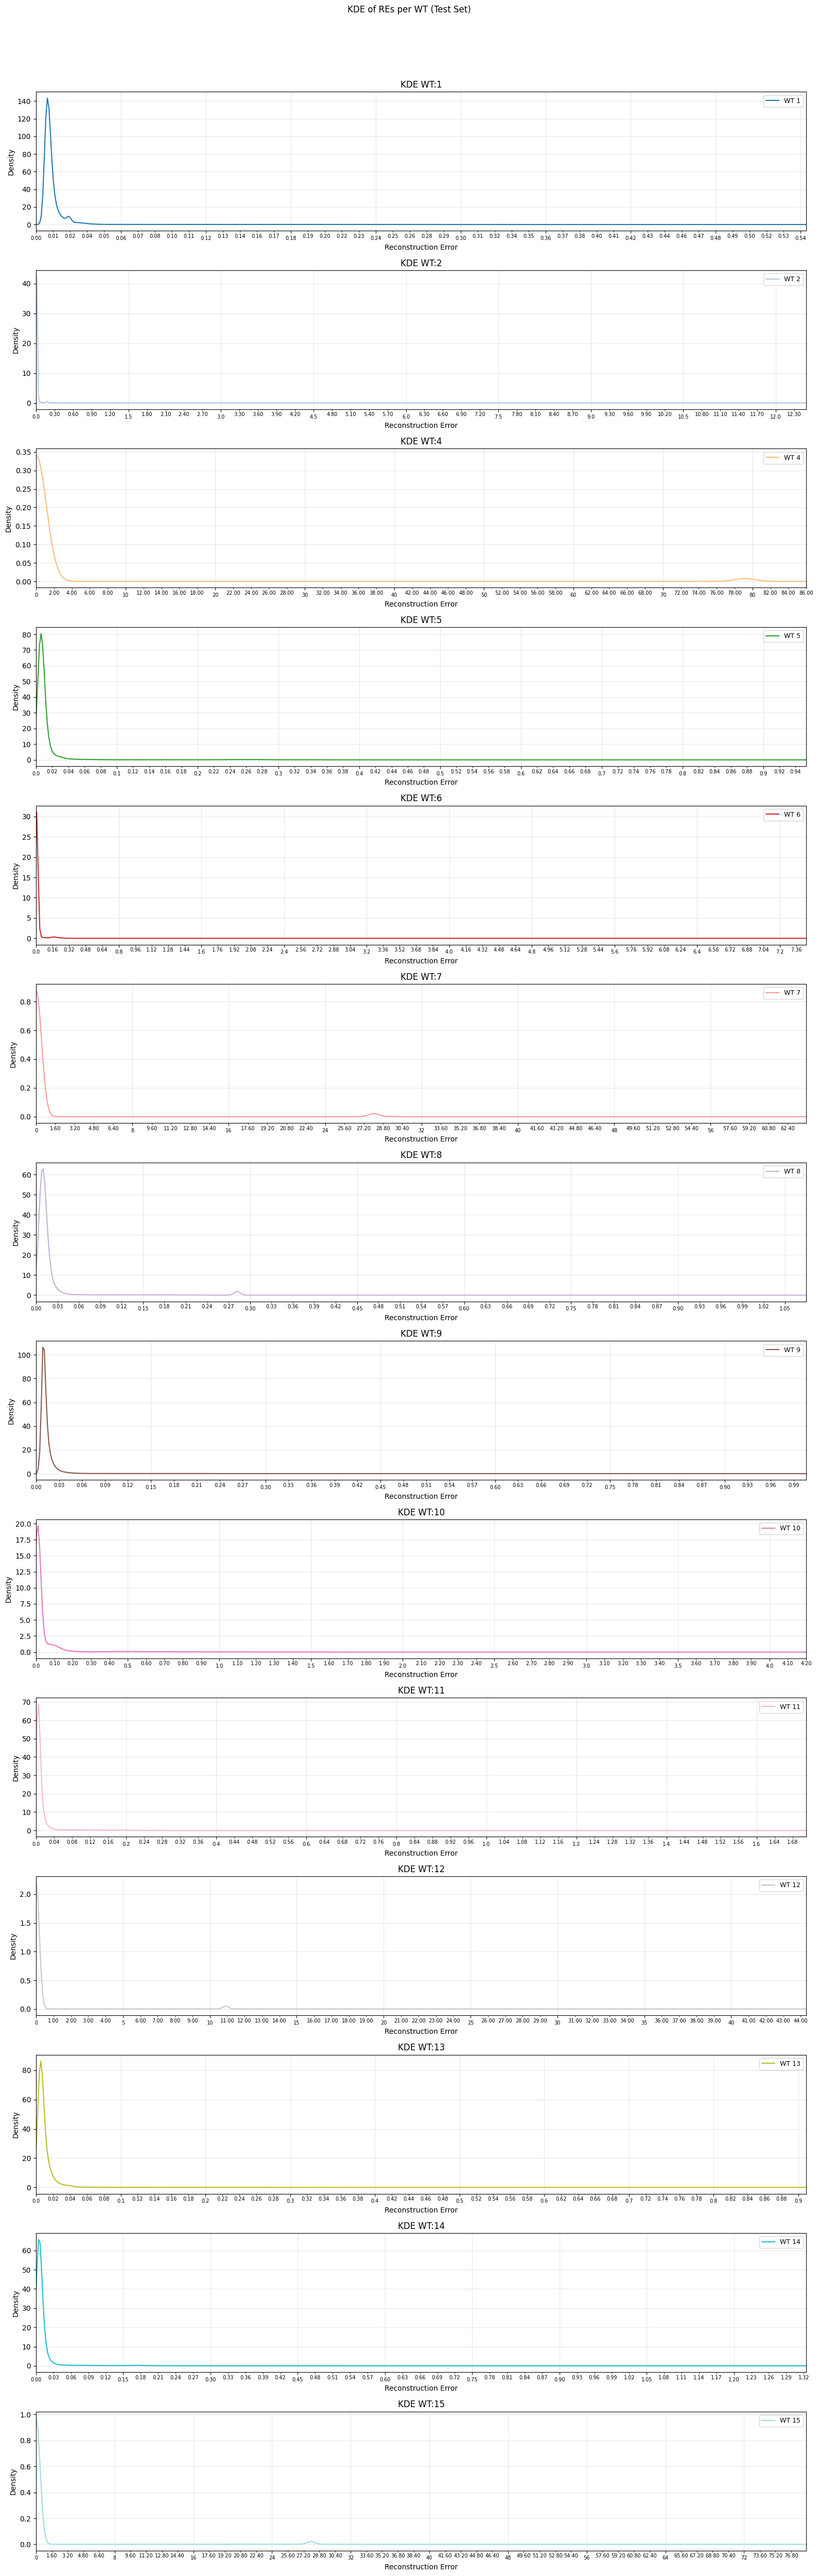

In [15]:
print_kdes(test_eval_df, title="KDE of REs per WT (Test Set)")

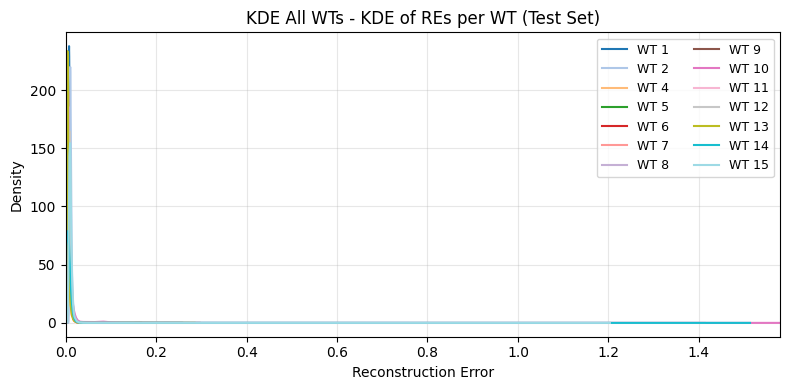

<Figure size 640x480 with 0 Axes>

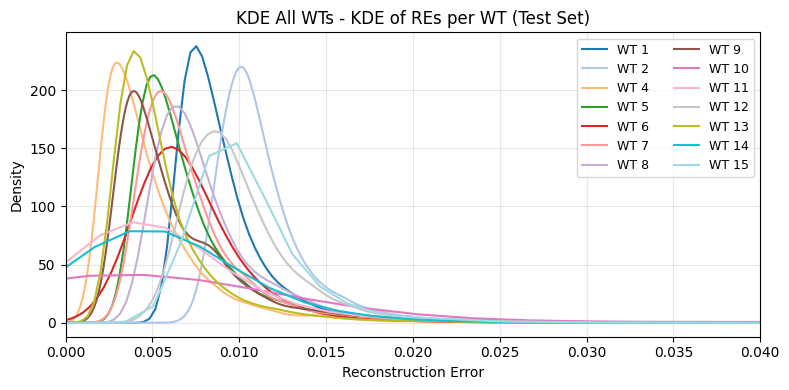

<Figure size 640x480 with 0 Axes>

In [16]:
print_kdes(test_eval_df, title="KDE of REs per WT (Test Set)", all_in_one=True, show_global_max=True)
print_kdes(test_eval_df, title="KDE of REs per WT (Test Set)", all_in_one=True, show_global_max=False, xlim=0.04)